<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1619/559971024.py:42: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Distribution of Magnitudes (excluding $\lambda=1$)")


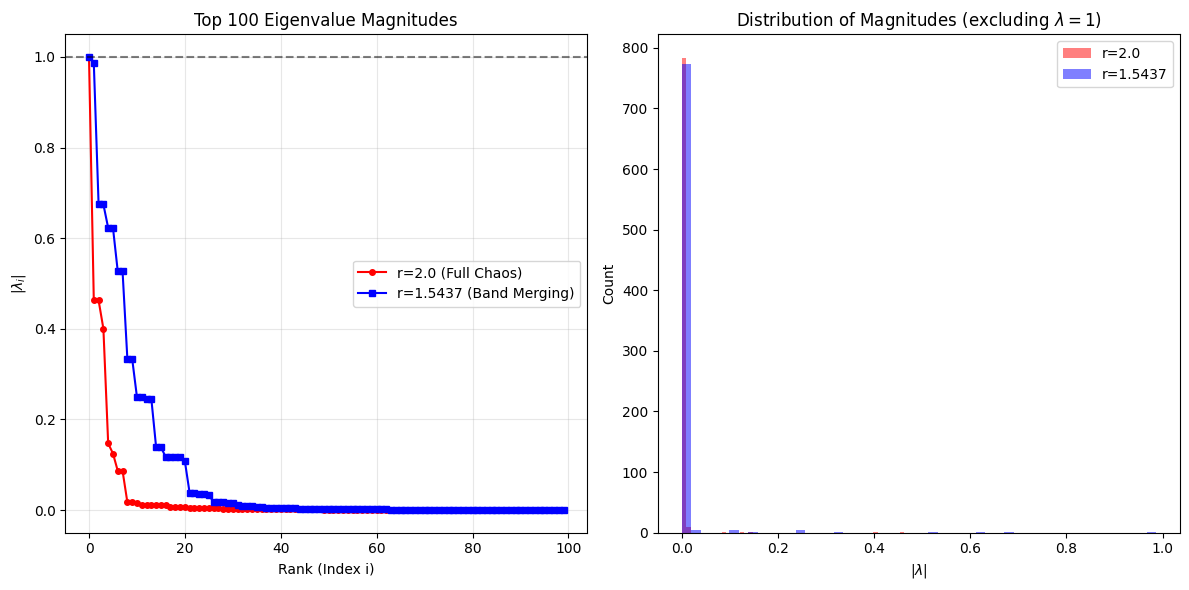

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def get_ulam_mags(r, N=800, epsilon=0.01):
    edges = np.linspace(-1, 1, N + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    P = np.zeros((N, N))
    
    # 构造带扩散的转移矩阵
    for j in range(N):
        x_next = 1 - r * (centers[j]**2)
        if -1.1 <= x_next <= 1.1:
            dist = np.abs(centers - x_next)
            kernel = np.exp(-dist**2 / (2 * epsilon**2))
            P[:, j] = kernel / kernel.sum()
            
    eigvals = np.linalg.eigvals(P)
    return np.sort(np.abs(eigvals))[::-1] # 降序排列模长

# 运行两个参数
mags_chaotic = get_ulam_mags(r=2.0)
mags_misiurewicz = get_ulam_mags(r=1.5437)

# 绘图
plt.figure(figsize=(12, 6))

# 1. 模长演化图 (Scree Plot)
plt.subplot(1, 2, 1)
plt.plot(mags_chaotic[:100], 'ro-', label='r=2.0 (Full Chaos)', markersize=4)
plt.plot(mags_misiurewicz[:100], 'bs-', label='r=1.5437 (Band Merging)', markersize=4)
plt.axhline(y=1.0, color='k', linestyle='--', alpha=0.5)
plt.title("Top 100 Eigenvalue Magnitudes")
plt.xlabel("Rank (Index i)")
plt.ylabel(r"$|\lambda_i|$")
plt.legend()
plt.grid(alpha=0.3)

# 2. 模长分布的直方图
plt.subplot(1, 2, 2)
plt.hist(mags_chaotic[1:], bins=50, alpha=0.5, color='red', label='r=2.0')
plt.hist(mags_misiurewicz[1:], bins=50, alpha=0.5, color='blue', label='r=1.5437')
plt.title("Distribution of Magnitudes (excluding $\lambda=1$)")
plt.xlabel(r"$|\lambda|$")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()